# Previsão de Churn de Clientes Bancários

**Dataset:** Cópia de ClientesBanco (10.127 registros, 21 colunas) — baseado no BankChurners (Credit Card Customers).

**Objetivo:** prever a coluna `Categoria` (Cliente vs Cancelado) a partir de dados demográficos e de uso de cartão, identificando os principais fatores de risco de churn.

**Etapas:**
1. Ingestão e validação dos dados
2. Análise exploratória (EDA)
3. Pré-processamento e engenharia de features
4. Modelagem (Random Forest)
5. Avaliação e explicabilidade (SHAP)
6. Conclusões e próximos passos


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


### Configuração do Ambiente Python

Nesta seção, importamos as bibliotecas necessárias para a análise e modelagem, e configuramos parâmetros básicos para visualização de dados e reproducibilidade. As bibliotecas incluem `pandas` para manipulação de dados, `numpy` para operações numéricas, `matplotlib` e `seaborn` para visualização, e módulos do `sklearn` para pré-processamento, modelagem e avaliação.

## 1. Ingestão dos dados

O CSV foi exportado com encoding `latin1` (não é UTF-8 puro, por isso especificamos o encoding manualmente). Validar isso antes de qualquer parsing evita erros silenciosos de caracteres acentuados.


In [7]:
import kagglehub
import pandas as pd
import os

# Faz o download direto do Kaggle (ignora o CSV local)
print("Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("sakshigoyal7/credit-card-customers")
csv_file = os.path.join(path, "BankChurners.csv")

# O dataset original do Kaggle tem 23 colunas, vamos dropar as 2 últimas que são Naive Bayes (lixo)
df = pd.read_csv(csv_file)
df = df.iloc[:, :-2] # removendo as colunas de Naive Bayes classifier

# Renomeando para ficar igual ao seu código original em português
df.columns = [
    "CLIENTNUM", "Categoria", "Idade", "Sexo", "Dependentes", "Educação",
    "Estado Civil", "Faixa Salarial Anual", "Categoria Cartão", "Meses como Cliente",
    "Produtos Contratados", "Inatividade 12m", "Contatos 12m", "Limite",
    "Limite Consumido", "Limite Disponível", "Mudanças Transacoes_Q4_Q1",
    "Valor Transacoes 12m", "Qtde Transacoes 12m", "Mudança Qtde Transações_Q4_Q1",
    "Taxa de Utilização Cartão"
]

# Substituindo os valores da Categoria para casar com o seu código (Attrited Customer -> Cancelado, Existing Customer -> Cliente)
df['Categoria'] = df['Categoria'].replace({'Attrited Customer': 'Cancelado', 'Existing Customer': 'Cliente'})

print(f"\nDataset pronto! Shape: {df.shape}")
df.head()


Shape: (10127, 21)


,CLIENTNUM,Categoria,Idade,Sexo,Dependentes,Educação,Estado Civil,Faixa Salarial Anual,Categoria Cartão,Meses como Cliente,...,Inatividade 12m,Contatos 12m,Limite,Limite Consumido,Limite Disponível,Mudanças Transacoes_Q4_Q1,Valor Transacoes 12m,Qtde Transacoes 12m,Mudança Qtde Transações_Q4_Q1,Taxa de Utilização Cartão
0,768805383,Cliente,45,M,3,Ensino Médio,Casado,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1335.0,1144,42,1625.0,0.061
1,818770008,Cliente,49,F,5,Ensino Superior,Solteiro,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1541.0,1291,33,3714.0,0.105
2,713982108,Cliente,51,M,3,Ensino Superior,Casado,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2594.0,1887,20,2333.0,0.000
3,769911858,Cliente,40,F,4,Ensino Médio,Não informado,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1405.0,1171,20,2333.0,0.760
4,709106358,Cliente,40,M,3,Sem ensino formal,Casado,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2175.0,816,28,2.5,0.000


### 1.1 Verificação da Qualidade dos Dados

Após a ingestão, é crucial realizar uma verificação inicial da qualidade dos dados. Isso inclui:
- **Tipos de dados**: Assegurar que cada coluna está com o tipo de dado correto (numérico, categórico, etc.).
- **Valores nulos**: Identificar a presença e a quantidade de valores nulos em cada coluna, o que pode indicar a necessidade de imputação ou remoção.
- **Registros duplicados**: Verificar a existência de linhas duplicadas, especialmente em identificadores únicos, para evitar contagens erradas ou viés na análise.

In [8]:
# Checagem básica de qualidade dos dados
print("Tipos de dados:")
print(df.dtypes)
print()
print("Valores nulos por coluna:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Duplicados (CLIENTNUM):", df["CLIENTNUM"].duplicated().sum())


Tipos de dados:
CLIENTNUM                          int64
Categoria                         object
Idade                              int64
Sexo                              object
Dependentes                        int64
Educação                          object
Estado Civil                      object
Faixa Salarial Anual              object
Categoria Cartão                  object
Meses como Cliente                 int64
Produtos Contratados               int64
Inatividade 12m                    int64
Contatos 12m                       int64
Limite                           float64
Limite Consumido                   int64
Limite Disponível                float64
Mudanças Transacoes_Q4_Q1        float64
Valor Transacoes 12m               int64
Qtde Transacoes 12m                int64
Mudança Qtde Transações_Q4_Q1    float64
Taxa de Utilização Cartão        float64
dtype: object

Valores nulos por coluna:
Categoria Cartão    1
dtype: int64

Duplicados (CLIENTNUM): 0


## 2. Análise exploratória (EDA)

A Análise Exploratória de Dados (EDA) é uma etapa fundamental para entender a estrutura, padrões e anomalias nos dados. Através de visualizações e estatísticas descritivas, buscaremos insights que possam influenciar as etapas de pré-processamento e modelagem.

## 2. Análise exploratória (EDA)

### 2.1 Distribuição da variável alvo


Categoria
Cliente      8500
Cancelado    1627
Name: count, dtype: int64

Taxa de churn: 16.07%


/tmp/ipykernel_5251/3319233694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Categoria", palette="Set2")


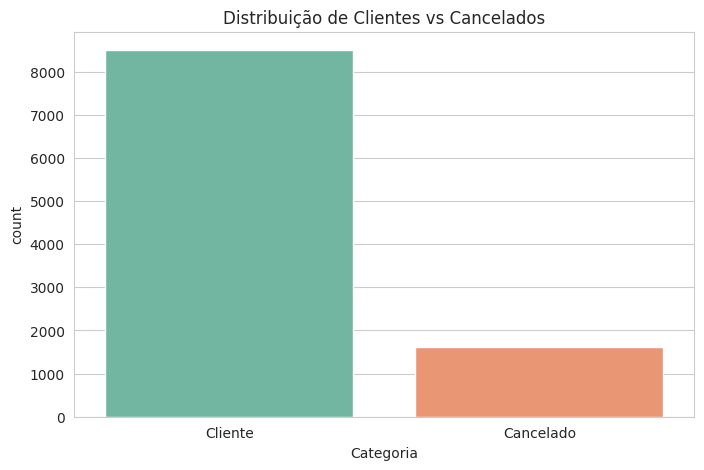

In [9]:
target_counts = df["Categoria"].value_counts()
print(target_counts)
print()
print(f"Taxa de churn: {target_counts['Cancelado'] / len(df):.2%}")

sns.countplot(data=df, x="Categoria", palette="Set2")
plt.title("Distribuição de Clientes vs Cancelados")
plt.show()


### 2.1 Distribuição da Variável Alvo

A variável alvo, 'Categoria', indica se o cliente permaneceu ativo ('Cliente') ou cancelou seus serviços ('Cancelado'). A análise de sua distribuição é crucial para entender o desbalanceamento das classes, o que pode impactar a escolha do modelo e das métricas de avaliação.

Este dataset apresenta um **desbalanceamento** de classes (aproximadamente 84% Cliente vs 16% Cancelado). Essa característica é crucial e será considerada na modelagem, através de técnicas como `class_weight='balanced'` e priorizando métricas como AUC e recall para a classe 'Cancelado'.

### 2.2 Distribuição das Variáveis Numéricas por Categoria de Churn

Box plots são utilizados para visualizar a distribuição das variáveis numéricas entre clientes ativos e clientes que cancelaram. Esta análise busca identificar diferenças significativas que podem indicar fatores de churn.

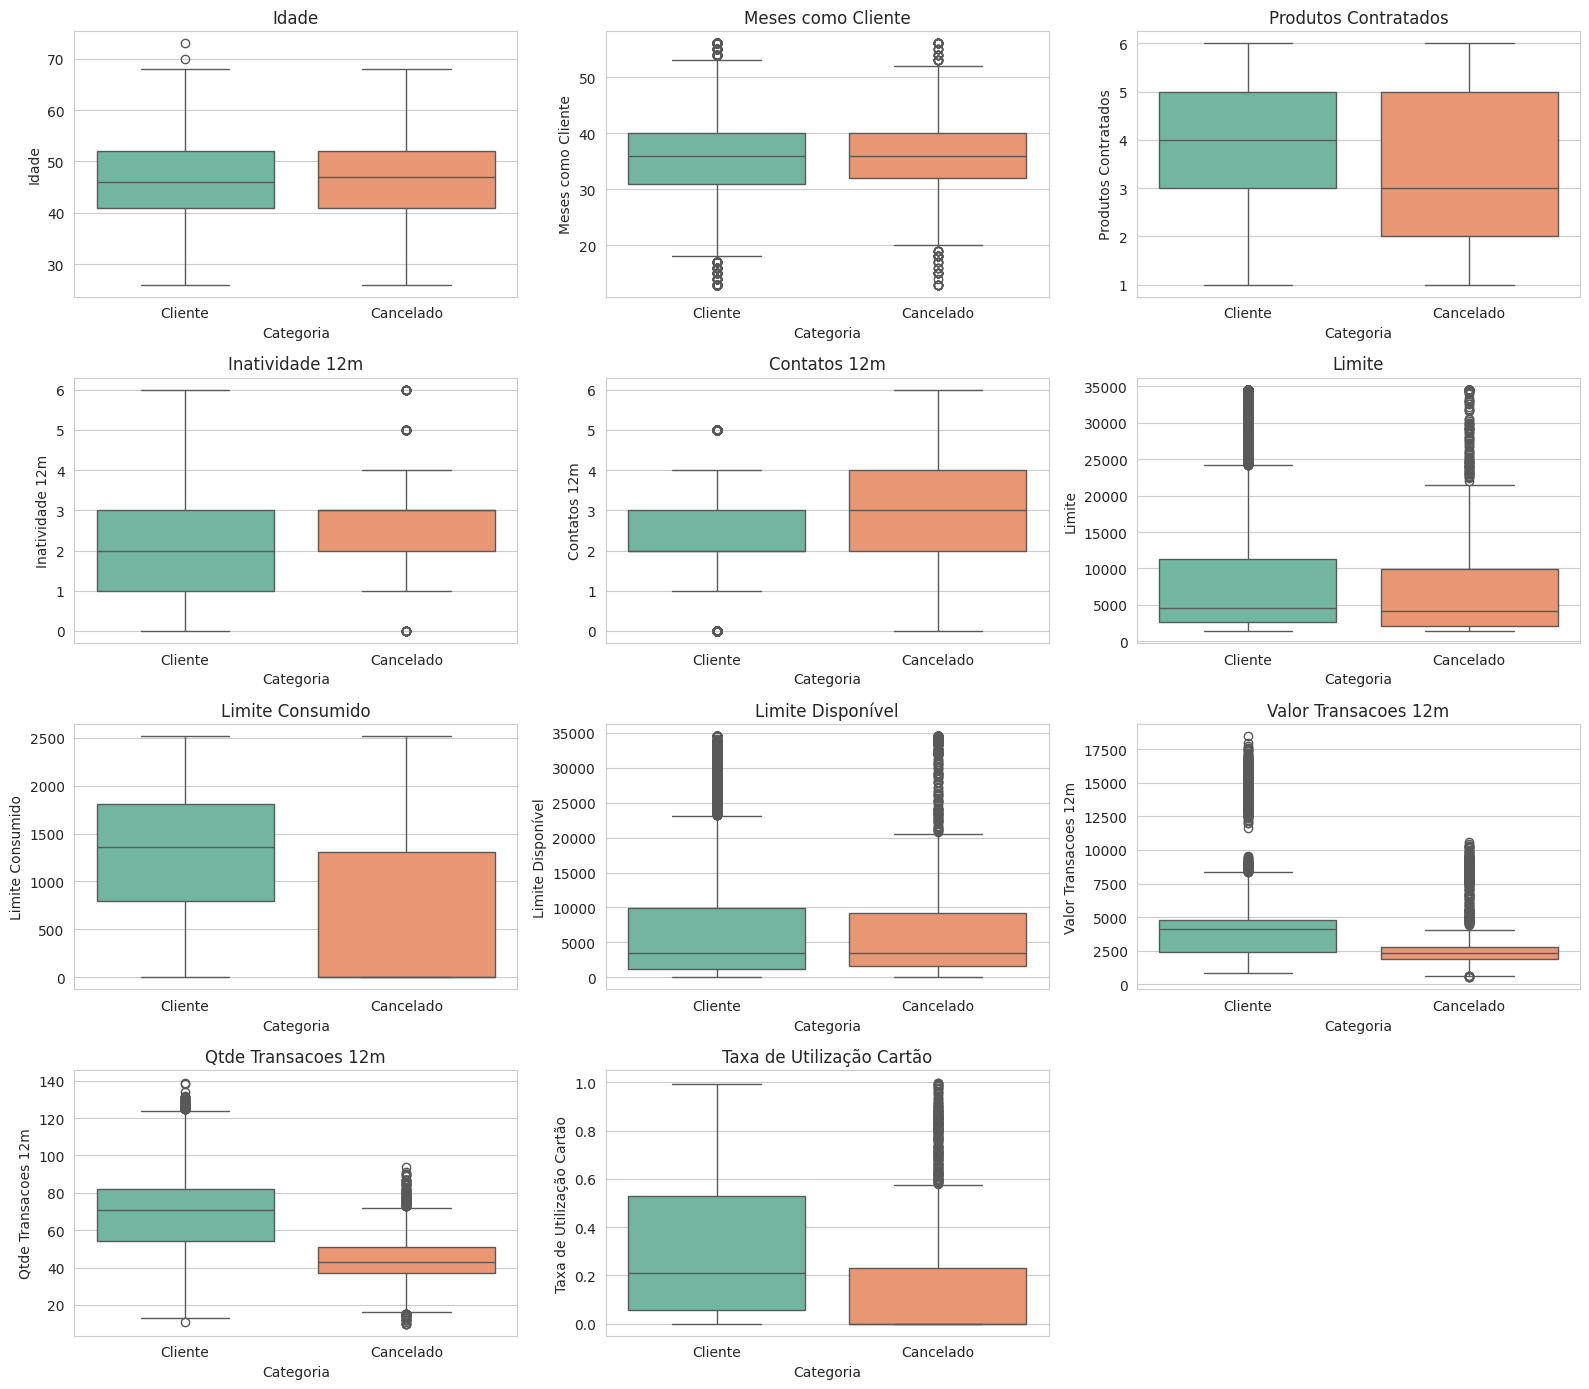

In [24]:
numeric_cols = [
    "Idade", "Meses como Cliente", "Produtos Contratados",
    "Inatividade 12m", "Contatos 12m", "Limite", "Limite Consumido",
    "Limite Disponível", "Valor Transacoes 12m", "Qtde Transacoes 12m",
    "Taxa de Utilização Cartão"
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="Categoria", y=col, ax=axes[i], palette="Set2", hue="Categoria", legend=False)
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.3 Variáveis Categóricas por Categoria de Churn

Para as variáveis categóricas, analisamos a taxa de churn para cada uma de suas categorias. Isso nos ajuda a identificar segmentos de clientes que possuem maior probabilidade de cancelar seus serviços, fornecendo insights importantes para estratégias de retenção.

### 2.3 Variáveis categóricas por categoria


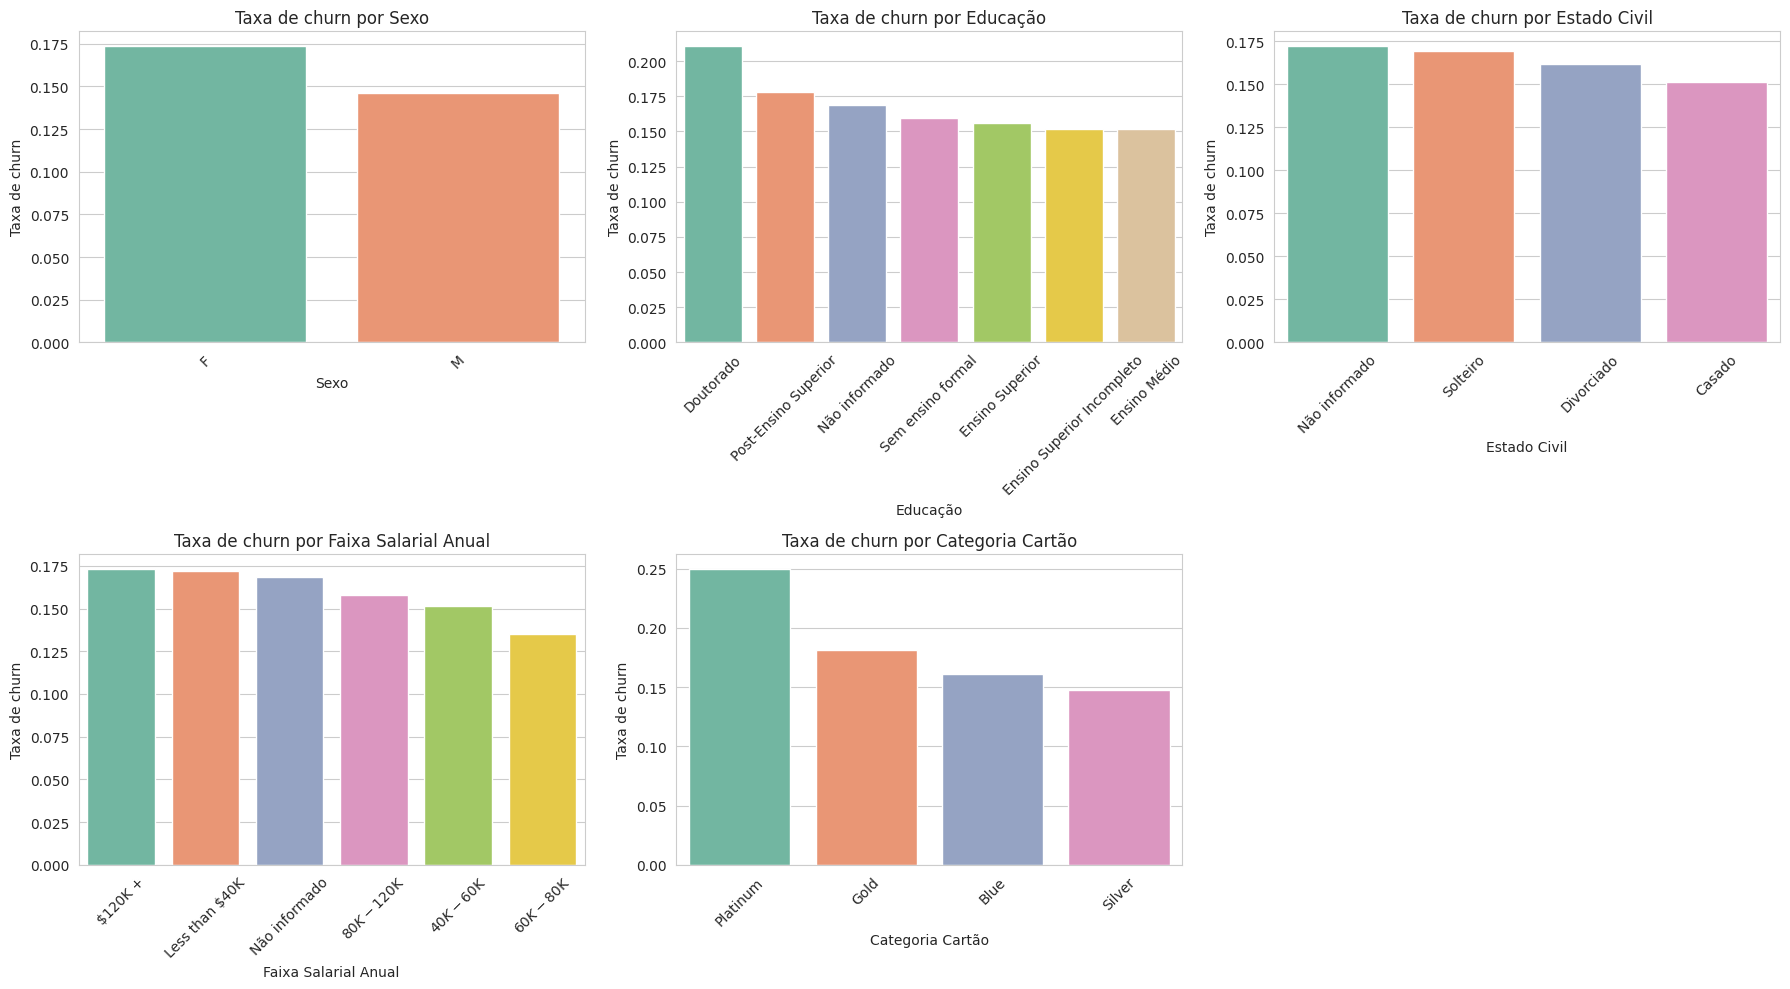

In [25]:
categorical_cols = ["Sexo", "Educação", "Estado Civil", "Faixa Salarial Anual", "Categoria Cartão"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)["Categoria"].apply(
        lambda x: (x == "Cancelado").mean()
    ).sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[i], palette="Set2", hue=churn_rate.index, legend=False)
    axes[i].set_title(f"Taxa de churn por {col}")
    axes[i].set_ylabel("Taxa de churn")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.4 Correlação entre Variáveis Numéricas

A matriz de correlação visualiza a relação linear entre pares de variáveis numéricas. Valores próximos a 1 ou -1 indicam forte correlação positiva ou negativa, respectivamente, enquanto valores próximos a 0 indicam pouca ou nenhuma correlação linear. Isso é útil para identificar multicolinearidade e para entender as interdependências nos dados.

### 2.4 Correlação entre variáveis numéricas


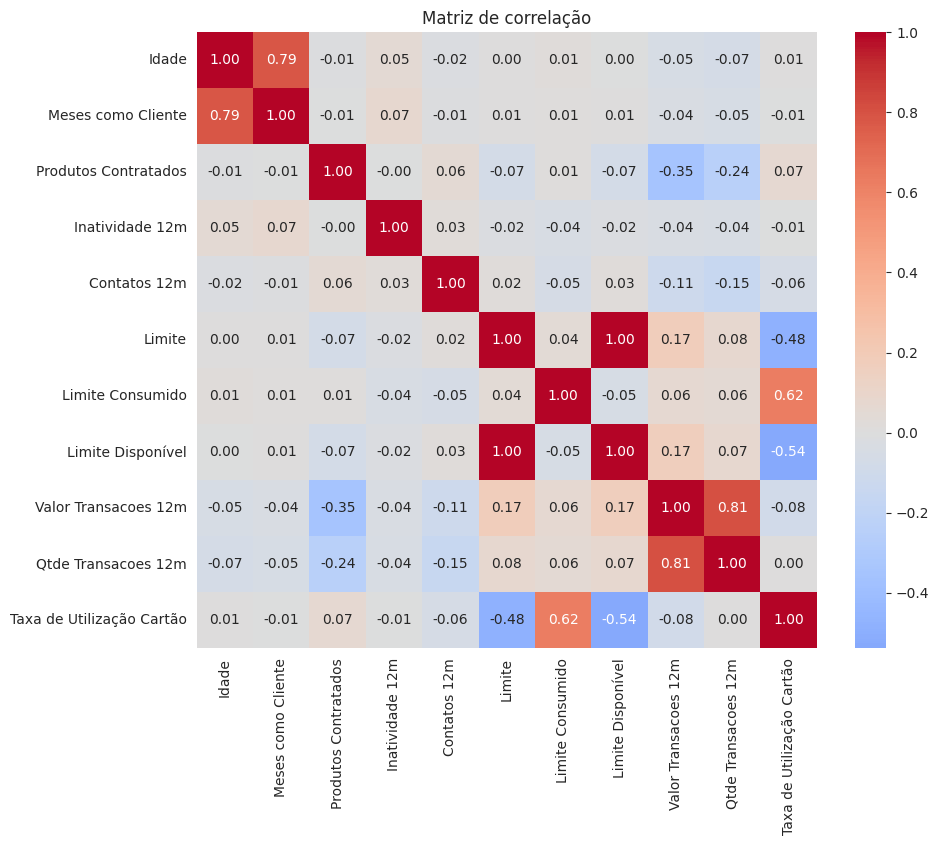

In [12]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação")
plt.show()


## 3. Pré-processamento e engenharia de features

Nesta etapa, preparamos os dados para a modelagem. Isso envolve a limpeza de dados, tratamento de valores ausentes, remoção de colunas irrelevantes e a codificação de variáveis categóricas para um formato que possa ser interpretado pelos algoritmos de aprendizado de máquina.

## 3. Pré-processamento e engenharia de features

Passos:
- Remover `CLIENTNUM` (identificador, não tem poder preditivo)
- Tratar nulos em `Categoria Cartão` (poucos registros — vamos imputar com a moda)
- Codificar variáveis categóricas
- Criar a variável alvo binária


In [13]:
df_model = df.copy()

# Remover identificador
df_model = df_model.drop(columns=["CLIENTNUM"])

# Imputar nulos em Categoria Cartão com a moda
moda_cartao = df_model["Categoria Cartão"].mode()[0]
df_model["Categoria Cartão"] = df_model["Categoria Cartão"].fillna(moda_cartao)

# Variável alvo binária: 1 = Cancelado, 0 = Cliente
df_model["target"] = (df_model["Categoria"] == "Cancelado").astype(int)
df_model = df_model.drop(columns=["Categoria"])

df_model.head()


,Idade,Sexo,Dependentes,Educação,Estado Civil,Faixa Salarial Anual,Categoria Cartão,Meses como Cliente,Produtos Contratados,Inatividade 12m,Contatos 12m,Limite,Limite Consumido,Limite Disponível,Mudanças Transacoes_Q4_Q1,Valor Transacoes 12m,Qtde Transacoes 12m,Mudança Qtde Transações_Q4_Q1,Taxa de Utilização Cartão,target
0,45,M,3,Ensino Médio,Casado,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1335.0,1144,42,1625.0,0.061,0
1,49,F,5,Ensino Superior,Solteiro,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1541.0,1291,33,3714.0,0.105,0
2,51,M,3,Ensino Superior,Casado,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2594.0,1887,20,2333.0,0.000,0
3,40,F,4,Ensino Médio,Não informado,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1405.0,1171,20,2333.0,0.760,0
4,40,M,3,Sem ensino formal,Casado,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2175.0,816,28,2.5,0.000,0


### 3.2 Codificação de Variáveis Categóricas

Variáveis categóricas precisam ser transformadas em um formato numérico para serem utilizadas por algoritmos de Machine Learning. O `Label Encoding` atribui um número único a cada categoria. Para casos de produção, `One-Hot Encoding` ou outros métodos podem ser mais apropriados para evitar a introdução de uma ordem artificial entre as categorias.

In [14]:
# Codificação de variáveis categóricas (Label Encoding para simplicidade;
# para produção, considere One-Hot Encoding ou encoders mais robustos)
categorical_to_encode = [
    "Sexo", "Educação", "Estado Civil", "Faixa Salarial Anual", "Categoria Cartão"
]

encoders = {}
for col in categorical_to_encode:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model.head()


,Idade,Sexo,Dependentes,Educação,Estado Civil,Faixa Salarial Anual,Categoria Cartão,Meses como Cliente,Produtos Contratados,Inatividade 12m,Contatos 12m,Limite,Limite Consumido,Limite Disponível,Mudanças Transacoes_Q4_Q1,Valor Transacoes 12m,Qtde Transacoes 12m,Mudança Qtde Transações_Q4_Q1,Taxa de Utilização Cartão,target
0,45,1,3,1,0,2,0,39,5,1,3,12691.0,777,11914.0,1335.0,1144,42,1625.0,0.061,0
1,49,0,5,2,3,4,0,44,6,1,2,8256.0,864,7392.0,1541.0,1291,33,3714.0,0.105,0
2,51,1,3,2,0,3,0,36,4,1,0,3418.0,0,3418.0,2594.0,1887,20,2333.0,0.000,0
3,40,0,4,1,2,4,0,34,3,4,1,3313.0,2517,796.0,1405.0,1171,20,2333.0,0.760,0
4,40,1,3,6,0,2,0,21,5,1,0,4716.0,0,4716.0,2175.0,816,28,2.5,0.000,0


## 4. Separação treino/teste e modelagem

Antes de treinar o modelo, dividimos o dataset em conjuntos de treino e teste. O conjunto de treino é usado para ensinar o modelo, enquanto o conjunto de teste é utilizado para avaliar seu desempenho em dados nunca vistos. Isso ajuda a garantir que o modelo generalize bem para novos dados.

### 4.1 Separação dos Dados

Utilizamos `stratify=y` na separação para garantir que a proporção das classes da variável alvo ('Cliente' vs 'Cancelado') seja mantida tanto no conjunto de treino quanto no de teste, o que é crucial em datasets desbalanceados.

## 4. Separação treino/teste e modelagem

Usamos `stratify=y` para manter a proporção de classes em ambos os conjuntos, dado o desbalanceamento.


In [15]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")


Treino: 8101 amostras
Teste: 2026 amostras


### 4.2 Treinamento do Modelo Random Forest

O Random Forest é um algoritmo de ensemble que constrói múltiplas árvores de decisão e combina suas previsões. Ele é robusto a overfitting e capaz de lidar com desbalanceamento de classes, especialmente quando `class_weight='balanced'` é utilizado. Os parâmetros `n_estimators` (número de árvores) e `max_depth` (profundidade máxima de cada árvore) são configurados para otimizar o desempenho.

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

## 5. Avaliação do Modelo

Após o treinamento, o modelo é avaliado usando métricas que medem sua capacidade de prever corretamente o churn. Como o dataset é desbalanceado, a acurácia por si só pode ser enganosa. Priorizamos métricas como `precision`, `recall`, `f1-score` para a classe 'Cancelado' e `AUC-ROC` (Area Under the Receiver Operating Characteristic Curve).

## 5. Avaliação do modelo


In [17]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Cliente", "Cancelado"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")


              precision    recall  f1-score   support

     Cliente       0.97      0.97      0.97      1701
   Cancelado       0.85      0.83      0.84       325

    accuracy                           0.95      2026
   macro avg       0.91      0.90      0.91      2026
weighted avg       0.95      0.95      0.95      2026

AUC-ROC: 0.9828


### 5.1 Matriz de Confusão

A matriz de confusão oferece uma visão detalhada do desempenho do modelo, mostrando as contagens de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos. É particularmente útil para entender os tipos de erros que o modelo está cometendo.

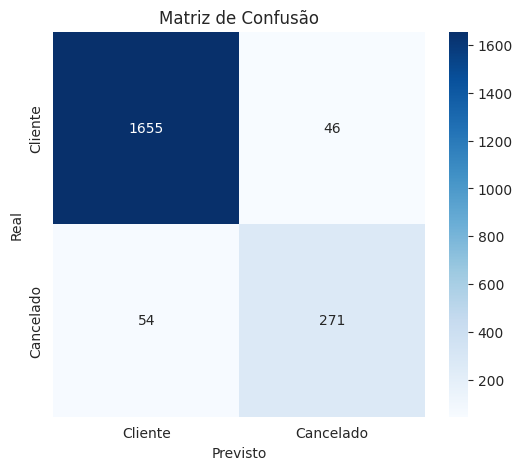

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cliente", "Cancelado"],
            yticklabels=["Cliente", "Cancelado"])
plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()


### 5.2 Curva ROC (Receiver Operating Characteristic)

A Curva ROC plota a Taxa de Verdadeiros Positivos (TPR) versus a Taxa de Falsos Positivos (FPR) em vários limiares de classificação. A Área Sob a Curva (AUC-ROC) é uma métrica agregada que mede a capacidade do modelo de distinguir entre as classes. Uma AUC próxima a 1 indica um modelo com excelente poder discriminatório.

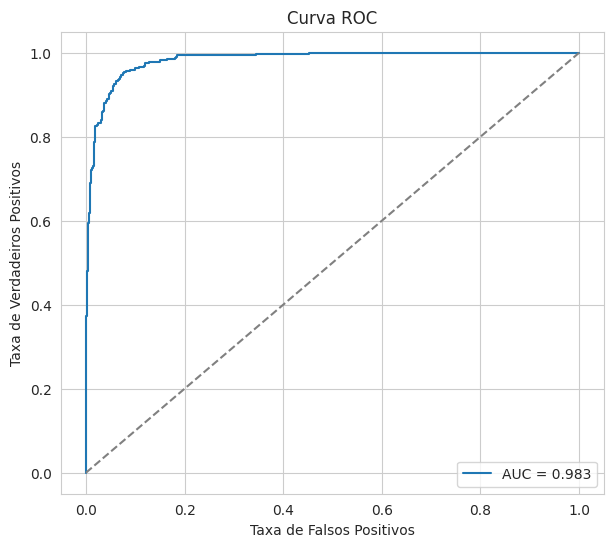

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()


## 6. Importância das features e explicabilidade

Compreender quais características são mais importantes para as previsões do modelo é crucial para extrair insights de negócio. Isso pode ajudar a identificar os principais fatores de risco de churn e a direcionar ações de marketing ou retenção.

## 6. Importância das features e explicabilidade

### 6.1 Importância nativa do Random Forest


/tmp/ipykernel_5251/2878996173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


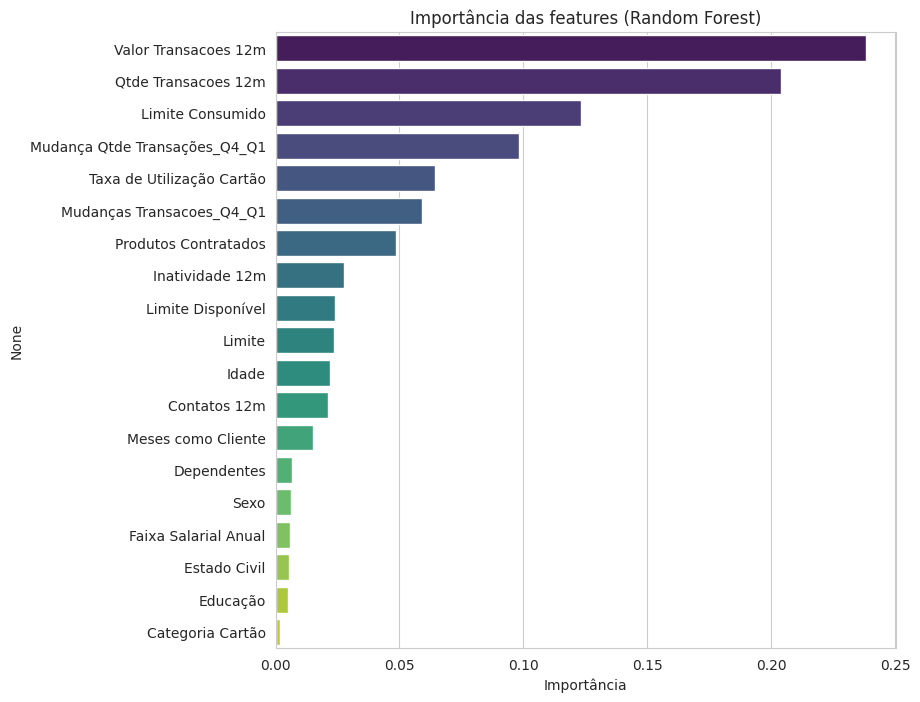

,0
Valor Transacoes 12m,0.238251
Qtde Transacoes 12m,0.204150
Limite Consumido,0.123069
Mudança Qtde Transações_Q4_Q1,0.098240
Taxa de Utilização Cartão,0.064491
Mudanças Transacoes_Q4_Q1,0.059266
Produtos Contratados,0.048605
Inatividade 12m,0.027513
Limite Disponível,0.023797
Limite,0.023500


In [20]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Importância das features (Random Forest)")
plt.xlabel("Importância")
plt.show()

importances


### 6.1 Importância Nativa do Random Forest

Modelos baseados em árvores, como o Random Forest, podem calcular a importância de cada feature. Esta métrica indica o quanto cada feature contribui para a redução da impureza (Gini impurity) ou para o ganho de informação na construção das árvores. Features com maior importância são as que mais influenciam as decisões do modelo.

### 6.2 SHAP (explicabilidade local e global)

Caso queira ir além da importância nativa, o SHAP detalha como cada feature empurra a previsão pra cima ou pra baixo, individualmente por cliente. Você já usou isso no notebook de XAI da faculdade — aqui é o mesmo princípio, aplicado a churn.


### 6.2 SHAP (SHapley Additive exPlanations)

O SHAP (SHapley Additive exPlanations) é uma técnica poderosa para explicar a saída de modelos de aprendizado de máquina. Ele atribui a cada feature um valor de importância para uma previsão específica. O gráfico de resumo SHAP (`shap.summary_plot`) abaixo mostra a importância das features de forma global:

- **Eixo Y**: Lista as features em ordem de importância decrescente (as mais importantes no topo).
- **Eixo X**: Representa o valor SHAP de cada feature. Quanto maior o valor absoluto de SHAP, maior o impacto da feature na previsão.
- **Cores**: Indicam o valor original da feature (vermelho para valores altos, azul para valores baixos).

Este gráfico nos permite entender não apenas quais features são importantes, mas também a *direção* de seu impacto (se valores altos da feature aumentam ou diminuem a probabilidade de churn) e a *distribuição* desse impacto.

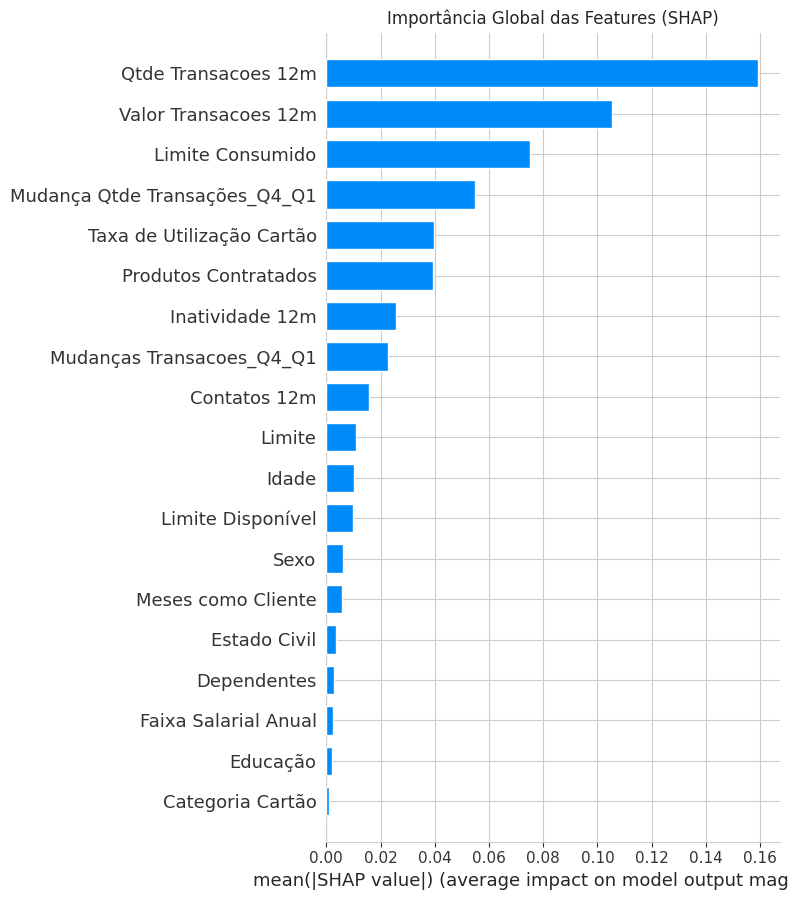

In [23]:
import shap

# Configure os logs para evitar mensagens desnecessárias do SHAP (opcional)
shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualiza a importância média absoluta das features
# O plot_type="bar" é útil para uma visão geral
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False)
plt.title("Importância Global das Features (SHAP)")
plt.tight_layout()
plt.show()

### Interpretação do Gráfico SHAP

O gráfico de barras SHAP acima mostra a importância global de cada feature para o modelo. Cada barra representa o impacto médio absoluto (magnitude SHAP) de uma feature na previsão da classe 'Cancelado'. Features no topo da lista são as que mais contribuem para a decisão do modelo, independentemente da direção (se aumentam ou diminuem a probabilidade de churn).

Para uma análise mais aprofundada, o SHAP também permite visualizar o impacto de cada feature para *instâncias individuais*, o que pode ser extremamente útil para entender por que um cliente específico é previsto como 'Cancelado'.

## 7. Conclusões e próximos passos

**Principais achados (a confirmar com os resultados acima):**
- Taxa de churn geral, e quais segmentos (faixa salarial, categoria de cartão, estado civil) têm maior propensão a cancelar.
- As features mais relevantes para prever churn segundo o modelo.
- Performance do modelo (AUC, precisão e recall para a classe "Cancelado", que é a que importa mais nesse tipo de problema de negócio).

**Próximos passos possíveis:**
- Testar outros modelos (XGBoost, LightGBM, Regressão Logística como baseline).
- Balancear classes com SMOTE em vez de apenas `class_weight`.
- Empacotar isso como pipeline (ingestão → limpeza → modelo → predição em batch ou via API).
- Persistir o modelo treinado (`joblib`/`pickle`) para reuso.
- Criar um dashboard simples (Streamlit) para visualizar o risco de churn por cliente.

## 7. Conclusões e próximos passos

**Principais achados (a confirmar com os resultados acima):**
- Taxa de churn geral, e quais segmentos (faixa salarial, categoria de cartão, estado civil) têm maior propensão a cancelar.
- As features mais relevantes para prever churn segundo o modelo.
- Performance do modelo (AUC, precisão e recall para a classe "Cancelado", que é a que importa mais nesse tipo de problema de negócio).

**Próximos passos possíveis:**
- Testar outros modelos (XGBoost, LightGBM, Regressão Logística como baseline).
- Balancear classes com SMOTE em vez de apenas `class_weight`.
- Empacotar isso como pipeline (ingestão → limpeza → modelo → predição em batch ou via API).
- Persistir o modelo treinado (`joblib`/`pickle`) para reuso.
- Criar um dashboard simples (Streamlit) para visualizar o risco de churn por cliente.
